In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
raw_path = "../data/raw"
processed_path = "../data/processed"

os.makedirs(processed_path, exist_ok=True)

In [4]:
files = sorted([f for f in os.listdir(raw_path) if f.endswith(".csv")])
files

['load_2018.csv',
 'load_2019.csv',
 'load_2020.csv',
 'load_2021.csv',
 'load_2022.csv',
 'load_2023.csv']

In [5]:
dfs = []

for file in files:
    path = os.path.join(raw_path, file)
    df = pd.read_csv(path)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.head()

,timestamp,load
0,2018-01-01 00:00:00+01:00,14978.54
1,2018-01-01 01:00:00+01:00,14397.65
2,2018-01-01 02:00:00+01:00,13789.46
3,2018-01-01 03:00:00+01:00,13434.45
4,2018-01-01 04:00:00+01:00,13285.24


In [7]:
data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True)

data = data.sort_values("timestamp")

data.reset_index(drop=True, inplace=True)

data.head()

,timestamp,load
0,2017-12-31 23:00:00+00:00,14978.54
1,2018-01-01 00:00:00+00:00,14397.65
2,2018-01-01 01:00:00+00:00,13789.46
3,2018-01-01 02:00:00+00:00,13434.45
4,2018-01-01 03:00:00+00:00,13285.24


In [8]:
print("Rows:", len(data))
print("Start:", data["timestamp"].min())
print("End:", data["timestamp"].max())

Rows: 52583
Start: 2017-12-31 23:00:00+00:00
End: 2023-12-31 22:00:00+00:00


In [9]:
data.isna().sum()

timestamp    0
load         0
dtype: int64

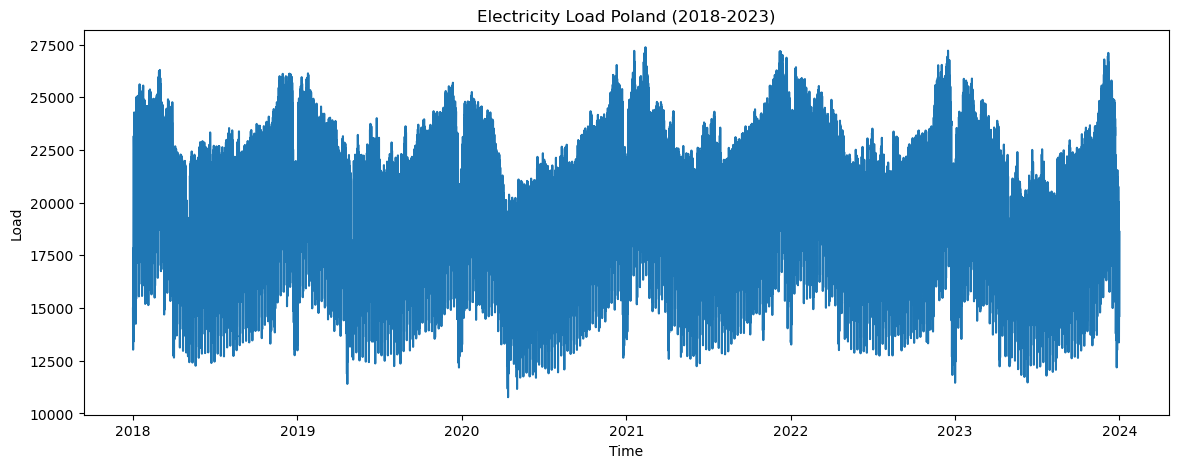

In [10]:
plt.figure(figsize=(14,5))
plt.plot(data["timestamp"], data["load"])
plt.title("Electricity Load Poland (2018-2023)")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

In [12]:
covid_start = pd.Timestamp("2020-03-01", tz="UTC")
covid_end = pd.Timestamp("2021-06-01", tz="UTC")
war_start = pd.Timestamp("2022-02-24", tz="UTC")

def label_period(ts):
    
    if covid_start <= ts <= covid_end:
        return "covid"
    
    if ts >= war_start:
        return "war"
    
    return "calm"

data["period"] = data["timestamp"].apply(label_period)

data.head()

,timestamp,load,period
0,2017-12-31 23:00:00+00:00,14978.54,calm
1,2018-01-01 00:00:00+00:00,14397.65,calm
2,2018-01-01 01:00:00+00:00,13789.46,calm
3,2018-01-01 02:00:00+00:00,13434.45,calm
4,2018-01-01 03:00:00+00:00,13285.24,calm


In [13]:
data["period"].value_counts()

period
calm     25391
war      16223
covid    10969
Name: count, dtype: int64

In [24]:
expected_range = pd.date_range(
    start=data["timestamp"].min(),
    end=data["timestamp"].max(),
    freq="h",
    tz="UTC"
)

missing = expected_range.difference(data["timestamp"])

print("Missing timestamps:", len(missing))

Missing timestamps: 0


In [17]:
duplicates = data["timestamp"].duplicated().sum()
print("Duplicate timestamps:", duplicates)

Duplicate timestamps: 0


In [18]:
data["load"].describe()

count    52583.000000
mean     19367.729278
std       3223.074461
min      10768.730000
25%      16685.320000
50%      19435.730000
75%      21862.335000
max      27374.680000
Name: load, dtype: float64

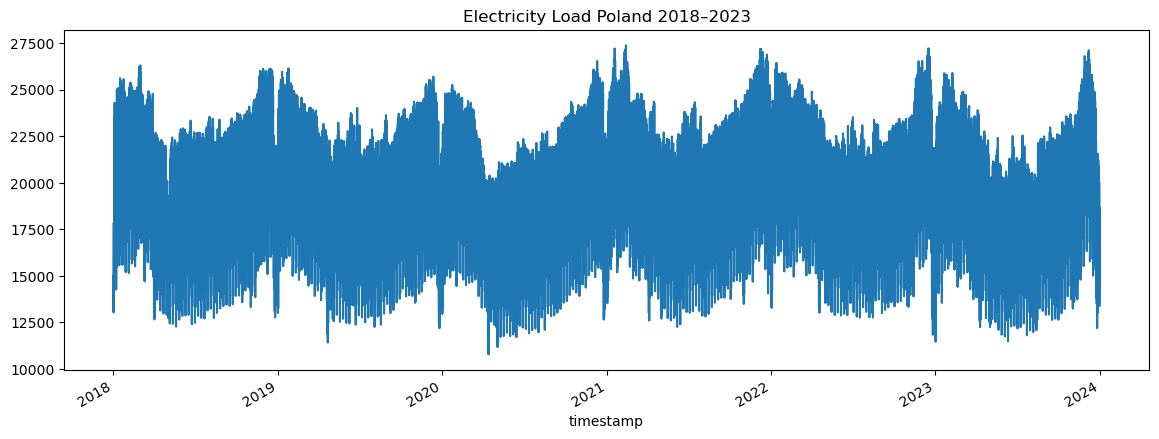

In [19]:
data.set_index("timestamp")["load"].plot(figsize=(14,5))
plt.title("Electricity Load Poland 2018–2023")
plt.show()

In [20]:
missing[:10]

DatetimeIndex(['2018-10-08 21:00:00+00:00'], dtype='datetime64[us, UTC]', freq='h')

In [23]:
# make sure timestamp is index
if data.index.name != "timestamp":
    data = data.set_index("timestamp")

# create full hourly timeline
full_range = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="h",
    tz="UTC"
)

# reindex dataset
data = data.reindex(full_range)

# fill missing load
data["load"] = data["load"].interpolate()

# reset index
data = data.reset_index().rename(columns={"index": "timestamp"})

In [25]:
output_path = os.path.join(processed_path, "electricity_clean.csv")

data.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: ../data/processed\electricity_clean.csv
